# El Niño Rainfall Composite and Event Distribution

This notebook plots El Niño rainfall-anomaly composites for P1 (1981–2006) and P2 (2007–2025) over the Maritime Continent, together with the distribution of El Niño events based on the DJF Niño 3.4 index.

### Plot Customization Guide:
- **`anom_levels`** and **`anom_ticks`**: Control the value range, color-contour interval, and colorbar ticks (−150 to 150).
- **`mc_extent`**: Defines the geographic boundaries of the plot (format: `[lon_min, lon_max, lat_min, lat_max]`).
- **`mc_xticks`** and **`mc_yticks`**: Control the latitude and longitude coordinate-label intervals on the map.
- **`rcParams`** in the import cell: Sets **Helvetica** (sans-serif) as the font and **16** as the default font size for all plot elements.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Configure matplotlib rcParams for Helvetica with a font size of 16
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

DATA_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/ElNinoComposite')
INTERMEDIATE_PATH = DATA_DIR / 'rainfall_elnino_mc_composites_significance_1.nc'
EVENT_PATH = DATA_DIR / 'elnino_event_selection_p1_p2_1.csv'
RESULTS_DIR = DATA_DIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

mc_extent = [80, 160, -20, 20]
mc_xticks = np.arange(90, 161, 20)
mc_yticks = np.arange(-20, 21, 10)

anom_levels = np.arange(-150, 151, 10)
anom_ticks = np.arange(-150, 151, 50)

In [2]:
ds = xr.open_dataset(INTERMEDIATE_PATH)
event_table = pd.read_csv(EVENT_PATH)

anom_p1 = ds['anomali_past']
sig_p1 = ds['signif_past'].astype(bool)
anom_p2 = ds['anomali_recent']
sig_p2 = ds['signif_recent'].astype(bool)

p1_vals = event_table.loc[event_table['period'] == 'P1', 'nino34'].dropna().to_numpy()
p2_vals = event_table.loc[event_table['period'] == 'P2', 'nino34'].dropna().to_numpy()

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


...

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


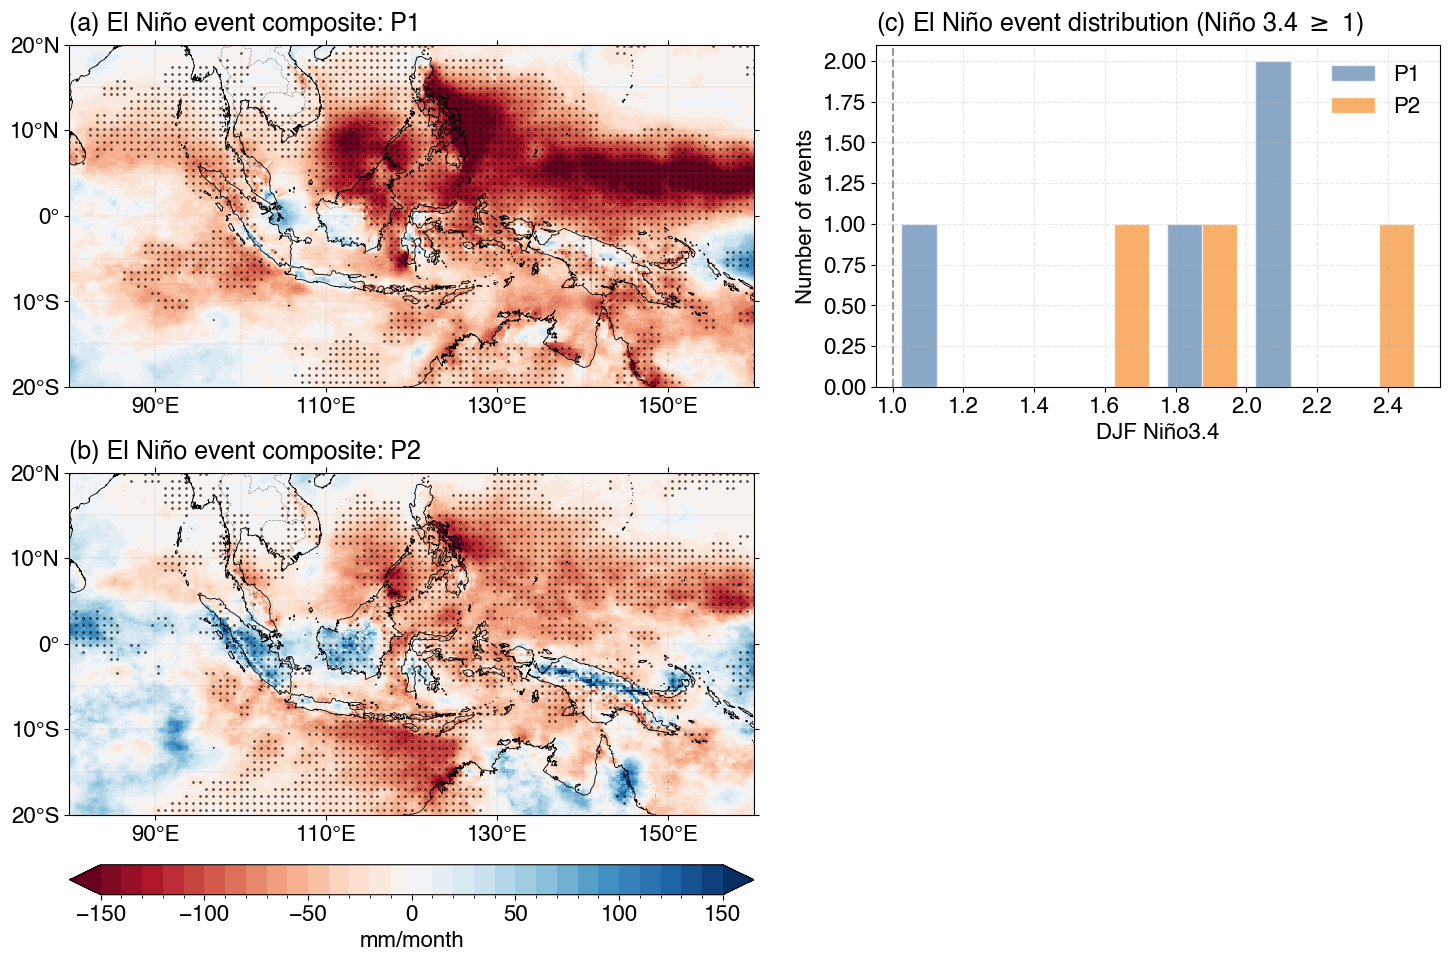

In [3]:
def add_stippling(ax, sig_mask, block=8, size=15, alpha=0.7):
    sig = sig_mask.fillna(False).astype(np.int8)
    sig_plot = (sig.coarsen(lat=block, lon=block, boundary='trim').max() > 0)
    yy, xx = np.where(sig_plot.values)
    if yy.size == 0:
        return
    ax.scatter(
        sig_plot['lon'].values[xx],
        sig_plot['lat'].values[yy],
        s=size,
        c='k',
        marker='.',
        linewidths=0,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

# =========================
# MANUAL LAYOUT PARAMETERS
# =========================
fig_width = 18
fig_height = 10

# Spacing
subplot_wspace = 0.15
subplot_hspace = 0.25

fig_left = 0.055
fig_right = 0.965
fig_bottom = 0.17
fig_top = 0.93

fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=subplot_hspace, wspace=subplot_wspace, 
                       width_ratios=[1.3, 1], height_ratios=[1, 1])

# Subplot a: P1 composite
ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
img_a = anom_p1.plot.pcolormesh(
    ax=ax_a,
    transform=ccrs.PlateCarree(),
    cmap='RdBu',
    levels=anom_levels,
    extend='both',
    add_colorbar=False,
    infer_intervals=True,
)
add_stippling(ax_a, sig_p1, block=8, size=15, alpha=0.7)
ax_a.coastlines(resolution='10m', linewidth=0.6, color='black', zorder=3)
ax_a.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, color='black', zorder=3)
ax_a.set_extent(mc_extent, crs=ccrs.PlateCarree())
ax_a.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
ax_a.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
ax_a.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
ax_a.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
ax_a.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
ax_a.tick_params(direction='out', top=True, right=True, labelsize=16)
ax_a.set_title('(a) El Niño event composite: P1', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_a.set_xlabel('')
ax_a.set_ylabel('')

# Subplot b: P2 composite
ax_b = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
img_b = anom_p2.plot.pcolormesh(
    ax=ax_b,
    transform=ccrs.PlateCarree(),
    cmap='RdBu',
    levels=anom_levels,
    extend='both',
    add_colorbar=False,
    infer_intervals=True,
)
add_stippling(ax_b, sig_p2, block=8, size=15, alpha=0.7)
ax_b.coastlines(resolution='10m', linewidth=0.6, color='black', zorder=3)
ax_b.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, color='black', zorder=3)
ax_b.set_extent(mc_extent, crs=ccrs.PlateCarree())
ax_b.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
ax_b.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
ax_b.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
ax_b.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
ax_b.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
ax_b.tick_params(direction='out', top=True, right=True, labelsize=16)
ax_b.set_title('(b) El Niño event composite: P2', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_b.set_xlabel('')
ax_b.set_ylabel('')

# Map colorbar (below subplot b)
fig.canvas.draw()
pos_b = ax_b.get_position()
cbar_ax = fig.add_axes([pos_b.x0, pos_b.y0 - 0.08, pos_b.width, 0.03])
cbar = fig.colorbar(img_b, cax=cbar_ax, orientation='horizontal', ticks=anom_ticks, spacing='proportional', extend='both', aspect=30, pad=0.02)
cbar.set_label('mm/month', fontsize=16)
cbar.ax.tick_params(labelsize=16)

# Subplot c: El Niño event distribution
ax_c = fig.add_subplot(gs[0, 1])
hist_min = 1.0
hist_max = 2.5
hist_bins = np.arange(hist_min, hist_max + 0.25, 0.25)
ax_c.hist([p1_vals, p2_vals], bins=hist_bins, label=['P1', 'P2'], color=['#4C78A8', '#F58518'], alpha=0.65, edgecolor='white')
ax_c.axvline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax_c.set_title('(c) El Niño event distribution (Niño 3.4 $\geq$ 1)', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_c.set_xlabel('DJF Niño3.4', fontsize=16)
ax_c.set_ylabel('Number of events', fontsize=16)
ax_c.legend(frameon=False, fontsize=16)
ax_c.grid(True, linestyle='--', alpha=0.3)
ax_c.set_ylim(0, 2.1)
ax_c.set_yticks(np.arange(0, 2.1, 0.25))
ax_c.tick_params(labelsize=16)

# Save the figure
fig.savefig(RESULTS_DIR / 'elnino_composite.png', dpi=300, bbox_inches='tight')
plt.show()
